In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings("ignore")

| Column Name            | Description                                                                 |
|------------------------|-----------------------------------------------------------------------------|
| `id`                   | Unique ID for the customer                                                  |
| `Gender`               | Gender of the customer                                                      |
| `Age`                  | Age of the customer                                                         |
| `Driving_License`      | `0`: Customer does not have a Driving License<br>`1`: Customer has a Driving License |
| `Region_Code`          | Unique code for the region of the customer                                  |
| `Previously_Insured`   | `1`: Customer already has Vehicle Insurance<br>`0`: Customer doesn't have Vehicle Insurance |
| `Vehicle_Age`          | Age of the Vehicle                                                          |
| `Vehicle_Damage`       | `1`: Customer got their vehicle damaged in the past<br>`0`: Customer didn't get their vehicle damaged in the past |
| `Annual_Premium`       | The amount the customer needs to pay as premium in a year                   |
| `Policy_Sales_Channel` | Anonymized code for the channel of reaching out to the customer (e.g., Agents, Mail, Phone, In Person) |
| `Vintage`              | Number of days the customer has been associated with the company            |
| `Response`             | `1`: Customer is interested<br>`0`: Customer is not interested              |


In [56]:
df = pd.read_csv("data.csv", index_col=False)
df.head(10)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
5,6,Female,24,1,33.0,0,< 1 Year,Yes,2630.0,160.0,176,0
6,7,Male,23,1,11.0,0,< 1 Year,Yes,23367.0,152.0,249,0
7,8,Female,56,1,28.0,0,1-2 Year,Yes,32031.0,26.0,72,1
8,9,Female,24,1,3.0,1,< 1 Year,No,27619.0,152.0,28,0
9,10,Female,32,1,6.0,1,< 1 Year,No,28771.0,152.0,80,0


In [57]:
#So Here we are renaming the columns 

col = []

for columns in (df.columns):
   col.append(columns.lower())

df.columns = col

In [58]:
df = df.drop(columns=['id'])

In [59]:
df.head(5)

,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [60]:
df["gender"] = df["gender"].map({'Male': 1, 'Female':0})
df['vehicle_age'] = df['vehicle_age'].map({'1-2 Year': 1, '< 1 Year': 0 ,'> 2 Years':2 })
df['vehicle_damage'] = df['vehicle_damage'].map({'Yes': 1, 'No':0})


In [61]:
df.head(10)

,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,44,1,28.0,0,2,1,40454.0,26.0,217,1
1,1,76,1,3.0,0,1,0,33536.0,26.0,183,0
2,1,47,1,28.0,0,2,1,38294.0,26.0,27,1
3,1,21,1,11.0,1,0,0,28619.0,152.0,203,0
4,0,29,1,41.0,1,0,0,27496.0,152.0,39,0
5,0,24,1,33.0,0,0,1,2630.0,160.0,176,0
6,1,23,1,11.0,0,0,1,23367.0,152.0,249,0
7,0,56,1,28.0,0,1,1,32031.0,26.0,72,1
8,0,24,1,3.0,1,0,0,27619.0,152.0,28,0
9,0,32,1,6.0,1,0,0,28771.0,152.0,80,0


In [62]:

for count in df.columns:
    print("----------------------------------")
    print(f"count of each columns : \n{df[count].value_counts()}")
    print("----------------------------------")


----------------------------------
count of each columns : 
gender
1    206089
0    175020
Name: count, dtype: int64
----------------------------------
----------------------------------
count of each columns : 
age
24    25960
23    24256
22    20964
25    20636
21    16457
      ...  
81       56
82       29
83       22
84       11
85       11
Name: count, Length: 66, dtype: int64
----------------------------------
----------------------------------
count of each columns : 
driving_license
1    380297
0       812
Name: count, dtype: int64
----------------------------------
----------------------------------
count of each columns : 
region_code
28.0    106415
8.0      33877
46.0     19749
41.0     18263
15.0     13308
30.0     12191
29.0     11065
50.0     10243
3.0       9251
11.0      9232
36.0      8797
33.0      7654
47.0      7436
35.0      6942
6.0       6280
45.0      5605
37.0      5501
18.0      5153
48.0      4681
14.0      4678
39.0      4644
10.0      4374
21.0      4266
2

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   gender                381109 non-null  int64  
 1   age                   381109 non-null  int64  
 2   driving_license       381109 non-null  int64  
 3   region_code           381109 non-null  float64
 4   previously_insured    381109 non-null  int64  
 5   vehicle_age           381109 non-null  int64  
 6   vehicle_damage        381109 non-null  int64  
 7   annual_premium        381109 non-null  float64
 8   policy_sales_channel  381109 non-null  float64
 9   vintage               381109 non-null  int64  
 10  response              381109 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 32.0 MB


In [64]:
df.describe()

,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,0.540761,38.822584,0.997869,26.388807,0.458210,0.609616,0.504877,30564.389581,112.034295,154.347397,0.122563
std,0.498336,15.511611,0.046110,13.229888,0.498251,0.567439,0.499977,17213.155057,54.203995,83.671304,0.327936
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,0.000000,25.000000,1.000000,15.000000,0.000000,0.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,1.000000,36.000000,1.000000,28.000000,0.000000,1.000000,1.000000,31669.000000,133.000000,154.000000,0.000000
75%,1.000000,49.000000,1.000000,35.000000,1.000000,1.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,1.000000,85.000000,1.000000,52.000000,1.000000,2.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [65]:
(df["driving_license"].value_counts()/df.shape[0])*100

driving_license
1    99.786938
0     0.213062
Name: count, dtype: float64

# **EDA**

In [66]:
df.shape

(381109, 11)

In [67]:
df.isnull().sum()

gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0
dtype: int64

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   gender                381109 non-null  int64  
 1   age                   381109 non-null  int64  
 2   driving_license       381109 non-null  int64  
 3   region_code           381109 non-null  float64
 4   previously_insured    381109 non-null  int64  
 5   vehicle_age           381109 non-null  int64  
 6   vehicle_damage        381109 non-null  int64  
 7   annual_premium        381109 non-null  float64
 8   policy_sales_channel  381109 non-null  float64
 9   vintage               381109 non-null  int64  
 10  response              381109 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 32.0 MB


In [69]:
(df['response'].value_counts()/df.shape[0])*100

response
0    87.743664
1    12.256336
Name: count, dtype: float64

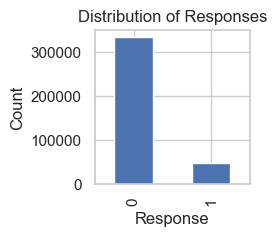

In [70]:
value_counts = df['response'].value_counts()

plt.figure(figsize=(2, 2))

# Create the bar plot
value_counts.plot(kind='bar')

# Customize the plot (optional)
plt.xlabel('Response')
plt.ylabel('Count')
plt.title('Distribution of Responses')

# Show the plot
plt.show()

<Axes: >

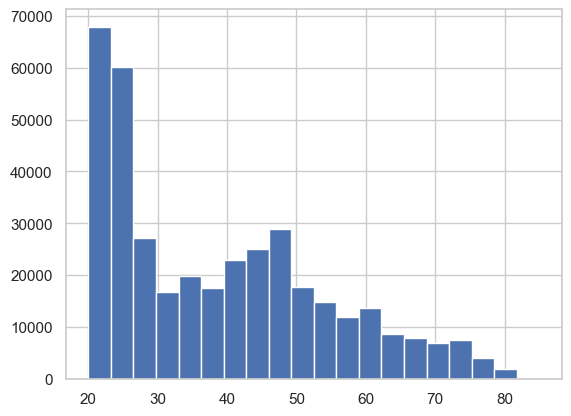

In [71]:
# checking distribution for age col
df['age'].hist(bins=20)

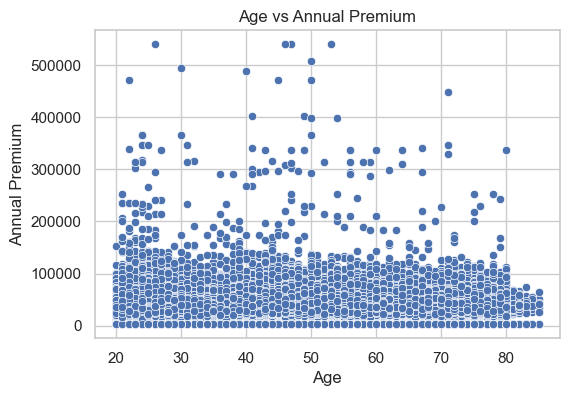

In [72]:
# Scatter Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='age', y='annual_premium', data=df)
plt.title('Age vs Annual Premium')
plt.xlabel('Age')
plt.ylabel('Annual Premium')
plt.show()

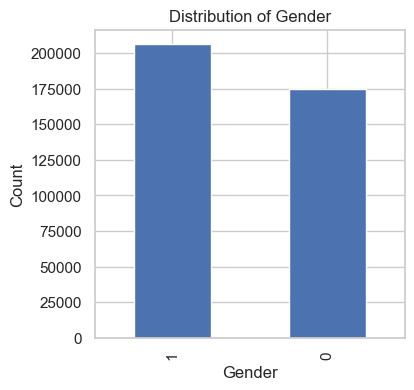

In [73]:
# Gender-Response comparison

value_counts = df['gender'].value_counts()
plt.figure(figsize=(4, 4))

# Create the bar plot
value_counts.plot(kind='bar')

# Customize the plot (optional)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')

# Show the plot
plt.show()

# Data Preprocessing


In [74]:
df.columns

Index(['gender', 'age', 'driving_license', 'region_code', 'previously_insured',
       'vehicle_age', 'vehicle_damage', 'annual_premium',
       'policy_sales_channel', 'vintage', 'response'],
      dtype='object')

In [75]:
numerical_features = ['age','vintage']
categorical_features = ['gender', 'driving_license', 'region_code', 'previously_insured',
       'vehicle_age', 'vehicle_damage', 'annual_premium',
       'policy_sales_channel', 'response']

In [76]:
# scaling the data

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

ss = StandardScaler()
df[numerical_features] = ss.fit_transform(df[numerical_features])


mm = MinMaxScaler()
df[['annual_premium']] = mm.fit_transform(df[['annual_premium']])


In [77]:
from sklearn.model_selection import train_test_split

# Separate the target variable and feature set
X = df.drop(columns=['response'])
y = df['response']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Model Trainer - Random Forest Classifier


In [78]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 3, 6],
    'max_depth': [10, None],
    'criterion': ['gini', 'entropy']
}

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

# Now this is valid
best_params = search.best_params_
print("Best Hyperparameters:")
print(best_params)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Hyperparameters:
{'n_estimators': 100, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_depth': 10, 'criterion': 'gini'}


In [79]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV

# my_params = {'n_estimators': 100, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_depth': 10, 'criterion': 'entropy'}

# clf = RandomForestClassifier()
# model = RandomizedSearchCV(estimator = clf, param_distributions = my_params, n_iter = 10, 
#                                cv = 4, verbose= 1, random_state= 101, n_jobs = -1)
# # for above line of code, feel free to make changes if can be made better

# model.fit(X_train,y_train)

In [80]:
# best_params = model.best_params_

# print("Best Hyperparameters:")
# print(best_params)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=7,
    min_samples_leaf=6,
    max_depth=10,
    criterion='entropy',
    random_state=101
)

model.fit(X_train, y_train)

# You cannot use `.best_params_` here
# Instead, just log what you already used
print("Model trained with:")
print(model.get_params())


Model trained with:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 6, 'min_samples_split': 7, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 101, 'verbose': 0, 'warm_start': False}


In [81]:
import pickle

filename = 'rf_model.pkl'
pickle.dump(model, open(filename, 'wb'))

In [82]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8774369604576107
Confusion Matrix:
 [[66880     0]
 [ 9342     0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.00      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.44      0.50      0.47     76222
weighted avg       0.77      0.88      0.82     76222



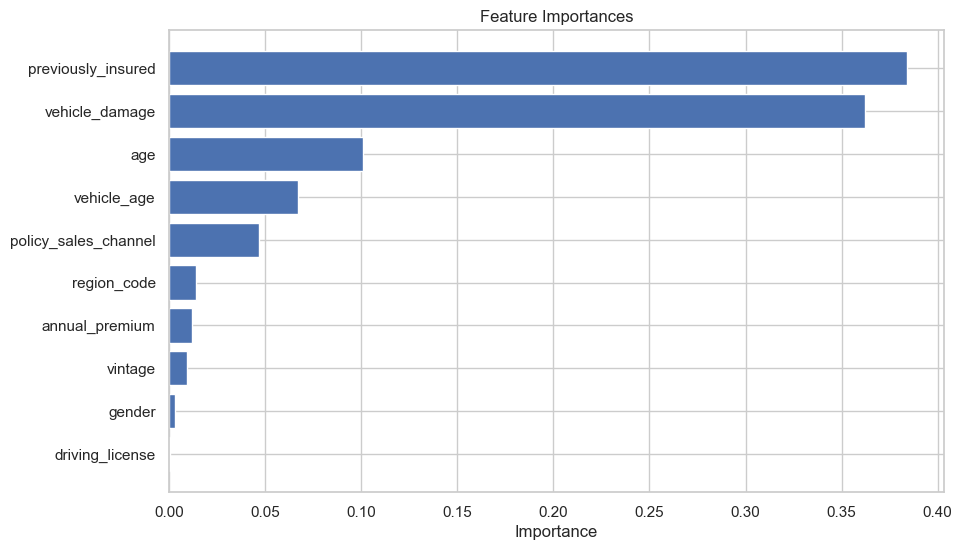

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importances
importances = model.feature_importances_
features = X_train.columns  # Make sure X_train is a DataFrame

# Create a DataFrame for plotting
feat_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_importance['Feature'], feat_importance['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.show()
